# 12교시 | Qwen3-VL 구조 분석
**환경**: RunPod A40 JupyterLab | **방법**: 이론 + 실습

---

## 학습 목표

- Qwen3-VL의 컴포넌트별 파라미터 분포를 코드로 직접 분석할 수 있다.
- 1~2일차에서 학습한 GPT-2, CLIP, Qwen3-VL을 구조적으로 비교 정리한다.

### 처음 읽는 분을 위한 안내

- 이번 교시를 한 줄로 보면: 지금까지 배운 개념이 최신 VLM(Vision Language Model) 하나 안에서 어떻게 합쳐지는지 실험으로 확인하는 시간이다.
- 처음에는 여기까지 이해하면 충분하다: 이미지가 시각 토큰으로 바뀌고, 텍스트와 함께 LLM(Large Language Model)으로 들어가 답변이 나온다는 흐름만 잡아도 된다.
- 헷갈려도 괜찮은 부분: 파라미터 수, GQA(Grouped Query Attention), 모듈 이름은 처음엔 부담스러울 수 있다. 먼저 각 부분이 어떤 역할을 하는지만 설명할 수 있어도 충분하다.

### 용어 미니사전

| 용어 | 아주 쉽게 말하면 |
|---|---|
| Visual Encoder | 이미지를 시각 토큰으로 바꾸는 부분 |
| Connector | 시각 표현을 LLM(Large Language Model) 차원으로 맞춰 주는 연결부 |
| GQA(Grouped Query Attention) | KV를 덜 저장하게 해 메모리를 줄이는 Attention 구조 |
| Image Token | 이미지가 모델 입력 안에서 차지하는 토큰 자리 |

---

## 구조 탐색

### 자주 막히는 오류

- 파라미터 표가 너무 커서 감이 안 옴: 먼저 "대부분은 LLM, 일부는 비전 인코더"라는 큰 비율부터 본다.
- Visual Encoder와 Language Model 역할이 헷갈림: 이미지는 먼저 visual encoder를 거치고, 최종 생성과 추론은 language model이 담당한다고 나눠서 본다.
- Qwen과 GPT 비교가 애매함: 길이나 말투보다 관찰 정보와 추론 방식의 차이를 먼저 본다.

### 실패했을 때 체크 순서

1. 지금 보는 출력이 전체 파라미터 분포인지, Visual Encoder 세부 구조인지, GQA 정보인지 먼저 고정한다.
2. 수치와 구조를 함께 본다: 파라미터 비율, 레이어 수, 헤드 수는 각각 다른 의미를 가진다.
3. 기준 모델과 기준 입력을 고정해 다시 실행한다: 이미지나 프롬프트를 동시에 바꾸지 않고 하나씩 비교한다.

### 이론 — Qwen3-VL 전체 아키텍처

#### 먼저 큰 그림부터 이해하기

이번 교시는 지금까지 배운 내용을 하나의 최신 VLM에 실제로 연결해 보는 시간이다.  
즉, 단순히 Qwen3-VL 코드를 실행하는 것이 아니라 아래 세 질문에 답할 수 있어야 한다.

1. 이미지는 어떤 경로로 LLM 입력까지 들어가는가?
2. Qwen3-VL은 왜 Visual Encoder와 Language Model이 함께 동작하는 구조로 설계되었는가?
3. GPT-2, CLIP, Qwen3-VL은 구조적으로 무엇이 같고 무엇이 다른가?

이 큰 그림을 잡고 실습을 보면, 각 코드는 단순한 사용 예제가 아니라 **모델 구조를 눈으로 확인하는 실험**이 된다.

```
입력: 이미지 + 텍스트 프롬프트

[이미지 처리 경로]
이미지 → 동적 타일 분할 (해상도에 따라 1~12개)
  ↓ 각 타일 → Qwen ViT (Visual Encoder)
  ↓ M-RoPE 2D 위치 인코딩 적용
  ↓ MLP Connector (ViT 차원 → LLM 차원 투영)
이미지 패치 토큰 시퀀스

[텍스트 처리 경로]
텍스트 → Tokenizer → 텍스트 토큰 시퀀스

[통합]
이미지 패치 토큰 + 텍스트 토큰
  ↓ Qwen3-8B LLM Decoder
  ↓ Causal Self-Attention
출력 텍스트 생성
```

이 흐름을 다시 말하면, Qwen3-VL은 `이미지 → 시각 토큰`, `텍스트 → 텍스트 토큰`으로 바꾼 뒤, 둘을 하나의 시퀀스로 통합해 Decoder가 답을 생성하는 구조다. 즉, VLM도 본질적으로는 여전히 다음 토큰 생성 모델이지만, 그 전에 **이미지를 언어 모델이 읽을 수 있는 형태로 번역하는 단계**가 추가되어 있다고 보면 된다.

**특수 토큰**
- `<|image_pad|>`: 이미지 패치 자리를 표시하는 플레이스홀더
- `<|vision_start|>` / `<|vision_end|>`: 이미지 시퀀스 경계 표시
- `<think>` / `</think>`: Thinking 모드의 추론 구간 구분

이 특수 토큰은 단순 표식이 아니라, LLM이 입력 안에서 이미지 경계와 추론 구간을 구조적으로 해석하는 데 도움을 준다.

---

### 실습 A — 파라미터 구조 분석

실습은 아래 순서대로 **한 단계씩 실행**하는 것을 권장한다.  
이번 12교시는 크게 네 부분이다.

1. Qwen3-VL 내부 파라미터 분포 분석
2. Visual Encoder와 LLM 구조 비교
3. GQA와 레이어 구성을 통한 메모리 구조 이해
4. GPT-2, CLIP, Qwen3-VL 구조 비교 정리

각 단계는 구조 이해를 위한 관찰 실습이므로, 출력 숫자와 구성 차이를 기록하면서 진행하는 것이 좋다.

#### Step A0. 구조 분석 실습 준비

이 단계는 11교시에서 만든 `/workspace/AE.2.1/.venv` 환경과 `Python (.venv) AE.2.1` 커널, 그리고 `/workspace/AE.2.1/models/Qwen3-VL-8B-Instruct` 로컬 모델 폴더가 이미 준비되어 있다는 전제로 진행한다.

In [1]:
import gc
from pathlib import Path

import torch
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor

MODEL_PATH = Path("/workspace/AE.2.1/models/Qwen3-VL-8B-Instruct")

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        "모델 폴더가 없습니다. 11교시 Step 6의 snapshot_download를 먼저 실행하세요: "
        "/workspace/AE.2.1/models/Qwen3-VL-8B-Instruct"
    )

def unload_qwen3vl():
    global model, processor

    if "model" in globals():
        del model
    if "processor" in globals():
        del processor

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


def load_qwen3vl(model_path, force_reload=False):
    global model, processor

    # 기본은 재사용, 필요할 때만 명시적으로 메모리 해제 후 다시 로딩
    if force_reload:
        unload_qwen3vl()

    if "model" in globals() and "processor" in globals():
        print("이미 로딩된 model/processor를 재사용합니다.")
        return model, processor

    processor = AutoProcessor.from_pretrained(model_path, local_files_only=True)
    model = Qwen3VLForConditionalGeneration.from_pretrained(
        model_path,
        torch_dtype=torch.bfloat16,
        attn_implementation="flash_attention_2",
        device_map="auto",
        local_files_only=True,
    )
    model.eval()
    return model, processor


# 기본 사용: 이미 로딩되어 있으면 재사용
model, processor = load_qwen3vl(MODEL_PATH)

# 강제 재로딩이 필요할 때만 사용
# model, processor = load_qwen3vl(MODEL_PATH, force_reload=True)

/workspace/AE.2.1/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 750/750 [00:01<00:00, 381.81it/s] 


이 단계에서 확인할 점:

- 11교시에서 준비한 모델이 정상적으로 재사용되는가?
- 같은 셀을 다시 실행해도 기본적으로는 기존 model/processor를 재사용하는가?
- 강제 재로딩이 필요할 때 `force_reload=True`로 GPU 메모리를 비운 뒤 다시 올릴 수 있는가?
- 로컬 경로와 `.venv` 커널을 기준으로 `processor`와 `model`이 읽히는가?
- 실습 대상이 visual encoder와 LLM으로 나뉜 구조임을 인지했는가?

#### Step A1. 전체 파라미터 분포 출력

In [3]:
# ── 전체 파라미터 분포 출력 ───────────────────────────────────
total_params = sum(p.numel() for p in model.parameters())

components = {
    "visual": model.model.visual,
    "language_model": model.model.language_model,
    "lm_head": model.lm_head,
}

print("=" * 60)
print(f"전체 파라미터: {total_params/1e9:.3f}B")
print("=" * 60)
print(f"\n{'컴포넌트':<40} {'파라미터':>10} {'비율':>8}")
print("-" * 60)

for name, module in components.items():
    cnt = sum(p.numel() for p in module.parameters())
    pct = cnt / total_params * 100
    print(f"{name:<40} {cnt/1e6:>8.1f}M {pct:>7.1f}%")

전체 파라미터: 8.767B

컴포넌트                                           파라미터       비율
------------------------------------------------------------
visual                                      576.4M     6.6%
language_model                             7568.4M    86.3%
lm_head                                     622.3M     7.1%


이 단계에서 확인할 점:

- `language_model`이 약 86%로 가장 크다는 점을 먼저 본다: 실제 생성과 추론의 중심이 언어 모델이라는 뜻이다.
- `visual`이 약 6.6%라는 점을 본다: 이미지 이해 모듈도 중요하지만, 전체 크기에서는 언어 모델보다 훨씬 작다.
- `lm_head`가 약 7.1%라는 점을 본다: 마지막 출력층도 생각보다 작지 않으며, 전체 어휘 출력과 연결된 부분이다.
- 즉, Qwen3-VL은 "이미지 모듈이 붙은 모델"이지만, 파라미터 대부분은 여전히 언어 모델에 들어 있다는 해석이 가능해야 한다.

#### Step A2. Visual Encoder와 LLM 세부 분석

In [4]:
# ── Visual Encoder 세부 분석 ──────────────────────────────────
print("\n[Visual Encoder 상세]")
vit = model.model.visual
vit_params = sum(p.numel() for p in vit.parameters())
print(f"타입     : {type(vit).__name__}")
print(f"파라미터 : {vit_params/1e9:.3f}B")
print(f"전체 비율: {vit_params/total_params*100:.1f}%")

# ViT 내부 레이어 탐색
for name, module in vit.named_children():
    cnt = sum(p.numel() for p in module.parameters())
    print(f"  {name:<35}: {cnt/1e6:.1f}M")

# ── LLM 레이어 분석 ───────────────────────────────────────────
print("\n[LLM (Language Model) 상세]")
llm = model.model.language_model  # Qwen3 기반 Text Decoder
llm_params = sum(p.numel() for p in llm.parameters())
print(f"레이어 수  : {llm.config.num_hidden_layers}")
print(f"어텐션 헤드: {llm.config.num_attention_heads}")
print(f"GQA 그룹수 : {llm.config.num_key_value_heads}")
print(f"d_model    : {llm.config.hidden_size}")
print(f"d_ffn      : {llm.config.intermediate_size}")
print(f"파라미터   : {llm_params/1e9:.3f}B")


[Visual Encoder 상세]
타입     : Qwen3VLVisionModel
파라미터 : 0.576B
전체 비율: 6.6%
  patch_embed                        : 1.8M
  pos_embed                          : 2.7M
  rotary_pos_emb                     : 0.0M
  blocks                             : 411.5M
  merger                             : 40.1M
  deepstack_merger_list              : 120.4M

[LLM (Language Model) 상세]
레이어 수  : 36
어텐션 헤드: 32
GQA 그룹수 : 8
d_model    : 4096
d_ffn      : 12288
파라미터   : 7.568B


이 단계에서 확인할 점:

- Visual Encoder가 약 0.576B, Language Model이 약 7.568B라는 점을 비교해 본다: 두 모듈의 규모 차이가 매우 크다는 것을 확인한다.
- Visual Encoder 내부에서는 `blocks` 비중이 가장 크다는 점을 본다: 실제 시각 처리의 핵심 파라미터가 Transformer block에 많이 들어 있음을 뜻한다.
- Language Model은 36개 레이어, 32개 Attention 헤드, 8개 KV 헤드를 가진다는 점을 읽는다: 큰 언어 모델 구조 위에 GQA가 적용된 형태라고 이해하면 된다.
- 특히 `num_attention_heads=32`, `num_key_value_heads=8`이므로 4개의 Query 헤드가 1개의 KV를 공유하는 구조라는 점까지 연결해서 해석할 수 있어야 한다.

#### Step A3. 파라미터 비율 시각화와 GQA 확인

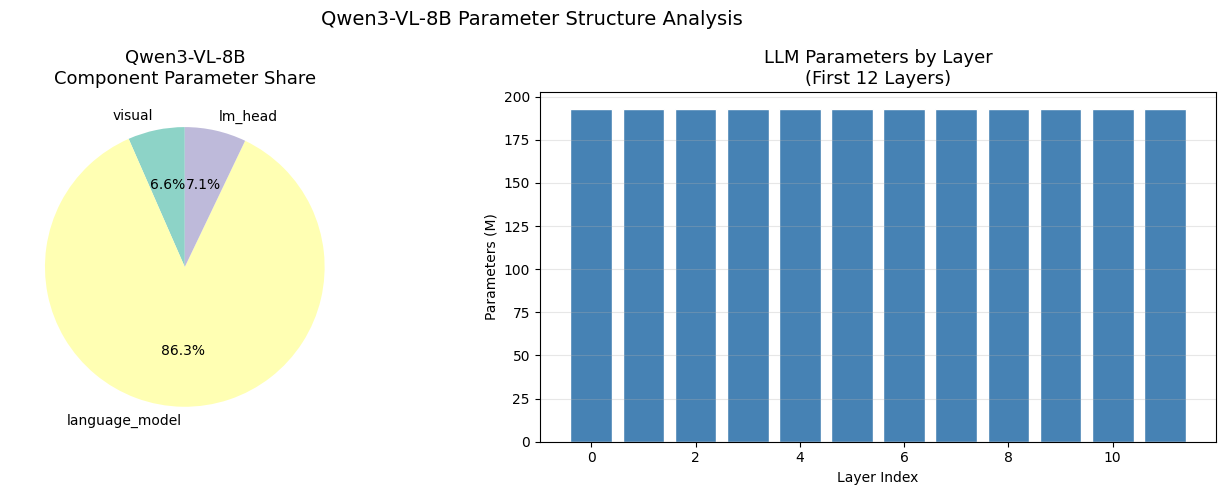


[GQA Structure]
Query heads : 32
KV heads    : 8
Sharing ratio: 4:1
→ KV cache is reduced by about 4x


In [6]:
# ── ViT vs LLM 파라미터 비율 시각화 ──────────────────────────
import matplotlib.pyplot as plt

components = {
    "visual": sum(p.numel() for p in model.model.visual.parameters()),
    "language_model": sum(p.numel() for p in model.model.language_model.parameters()),
    "lm_head": sum(p.numel() for p in model.lm_head.parameters()),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 파이 차트
wedges, texts, autotexts = axes[0].pie(
    list(components.values()),
    labels=list(components.keys()),
    autopct="%1.1f%%",
    startangle=90,
    colors=plt.cm.Set3.colors
)
axes[0].set_title("Qwen3-VL-8B\nComponent Parameter Share", fontsize=13)

# LLM 레이어별 파라미터 (첫 몇 레이어)
layer_params = []
for i, layer in enumerate(llm.layers[:12]):
    cnt = sum(p.numel() for p in layer.parameters())
    layer_params.append(cnt / 1e6)

axes[1].bar(range(len(layer_params)), layer_params, color='steelblue', edgecolor='white')
axes[1].set_xlabel("Layer Index")
axes[1].set_ylabel("Parameters (M)")
axes[1].set_title("LLM Parameters by Layer\n(First 12 Layers)", fontsize=13)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle("Qwen3-VL-8B Parameter Structure Analysis", fontsize=14)
plt.tight_layout()
plt.show()

# ── GQA(Grouped-Query Attention) 확인 ────────────────────────
print("\n[GQA Structure]")
print(f"Query heads : {llm.config.num_attention_heads}")
print(f"KV heads    : {llm.config.num_key_value_heads}")
print(f"Sharing ratio: {llm.config.num_attention_heads // llm.config.num_key_value_heads}:1")
print(f"→ KV cache is reduced by about {llm.config.num_attention_heads // llm.config.num_key_value_heads}x")

이 단계에서 확인할 점:

- 파이 차트가 `visual`, `language_model`, `lm_head` 세 부분으로 나뉘는지 확인한다: Step A1의 표와 같은 기준이어야 한다.
- 시각화로 보았을 때 `language_model` 비중이 압도적으로 큰지 다시 한 번 눈으로 확인한다.
- 막대그래프에서 앞 12개 LLM 레이어의 파라미터 수가 거의 비슷하게 보이는지 확인한다: 각 레이어가 비슷한 규모로 반복되는 Transformer 구조라는 뜻이다.
- GQA 출력에서 32 Query 헤드와 8 KV 헤드가 보여, 4:1 공유 구조로 해석되는지 확인한다.

---

### 정리 B — GPT-2, CLIP, Qwen3-VL 구조 비교

앞에서 본 Qwen3-VL 구조를 1~2일차 모델과 연결해서 보면, 각 모델이 어떤 입력을 받고 무엇을 목표로 설계되었는지 더 선명하게 정리할 수 있다.

| 모델 | 핵심 입력 | 중심 구조 | 학습/사용 목적 | 생성 가능 여부 |
|---|---|---|---|---|
| GPT-2 | 텍스트 | Decoder-only Transformer | 다음 토큰 예측 | 가능 |
| CLIP | 이미지 + 텍스트 | Image Encoder + Text Encoder | 두 입력을 같은 임베딩 공간에 정렬 | 직접 생성하지 않음 |
| Qwen3-VL | 이미지 + 텍스트 | Visual Encoder + Connector + Decoder LLM | 멀티모달 이해 + 텍스트 생성 | 가능 |

비교해서 보면 핵심 차이는 다음과 같다.

- GPT-2는 텍스트만 받아 다음 토큰을 생성하는 가장 기본적인 Decoder 구조다.
- CLIP은 이미지와 텍스트를 각각 인코딩한 뒤 같은 의미 공간에서 가깝게 맞추는 모델이라, 생성보다는 정렬과 검색에 강하다.
- Qwen3-VL은 CLIP처럼 이미지를 먼저 이해하는 경로가 있고, 그 결과를 GPT-2 계열처럼 동작하는 Decoder LLM으로 넘겨 최종 텍스트를 생성한다.
- 즉, Qwen3-VL은 "비전 인코더 + 언어 생성기"가 결합된 구조로 이해하면 된다.

이 단계에서 확인할 점:

- GPT-2는 텍스트 전용 생성 모델, CLIP은 정렬 모델, Qwen3-VL은 멀티모달 생성 모델이라는 구분이 되는지 확인한다.
- CLIP에는 생성용 `lm_head`가 없지만, Qwen3-VL에는 language model과 `lm_head`가 있다는 점을 연결해서 본다.
- Qwen3-VL이 새 모델이라기보다, "이미지 이해 경로"와 "텍스트 생성 경로"를 결합한 구조라는 점을 설명할 수 있어야 한다.

---

## 핵심 개념 정리

```
Qwen3-VL-8B 구조 핵심
Visual Encoder: 이미지 → 시각 표현
Connector / Projection: 시각 표현 → LLM 입력 차원 정렬
Language Model: 텍스트 생성과 추론 담당
GQA: KV Cache 메모리 절약 구조
M-RoPE: 멀티모달 위치 정보 처리
```

### 혼자 점검하기

아래 질문에 막힘 없이 답하면 구조 분석 이해가 잘 된 것이다.

1. Qwen3-VL에서 Visual Encoder와 Language Model은 각각 어떤 역할을 하는가?
2. 전체 파라미터 중 어느 컴포넌트가 가장 큰 비중을 차지하는가?
3. GQA는 왜 KV Cache 메모리 절약과 연결되는가?
4. `num_attention_heads`와 `num_key_value_heads`의 차이는 무엇을 뜻하는가?
5. Qwen3-VL의 구조를 GPT-2나 CLIP과 비교하면 어떤 차이가 있는가?

---

## 부록 | 혼자 점검 모범 답안

이 부록은 교육생이 12교시의 구조 분석 결과를 질문에 맞춰 스스로 설명해 볼 때 참고할 수 있는 해설이다.

### 혼자 점검하기 모범 답안

**1. Qwen3-VL에서 Visual Encoder와 Language Model은 각각 어떤 역할을 하는가?**

Visual Encoder는 이미지를 시각 토큰 또는 시각 표현으로 바꾸는 역할을 한다. Language Model은 그렇게 변환된 시각 정보와 텍스트 정보를 함께 받아 최종 텍스트를 생성한다.

**2. 전체 파라미터 중 어느 컴포넌트가 가장 큰 비중을 차지하는가?**

대체로 Language Model이 가장 큰 비중을 차지한다. 이는 Qwen3-VL이 멀티모달 모델이지만, 실제 생성과 추론의 중심은 여전히 대형 언어 모델이라는 점을 보여준다.

**3. GQA는 왜 KV Cache 메모리 절약과 연결되는가?**

GQA는 Query 헤드보다 적은 수의 Key/Value 헤드를 공유하므로, 저장해야 할 KV 수를 줄일 수 있다. 그 결과 추론 시 KV Cache 메모리 사용량이 감소한다.

**4. `num_attention_heads`와 `num_key_value_heads`의 차이는 무엇을 뜻하는가?**

전체 Attention 헤드 수와 실제로 공유되는 KV 헤드 수가 다르다는 뜻이다. 두 값의 차이가 클수록 더 많은 Query 헤드가 같은 KV를 공유하게 되며, 이는 메모리 절약과 연결된다.

**5. Qwen3-VL의 구조를 GPT-2나 CLIP과 비교하면 어떤 차이가 있는가?**

GPT-2는 텍스트만 다루는 Decoder 중심 모델이고, CLIP은 이미지와 텍스트를 같은 임베딩 공간에 정렬하는 모델이다. Qwen3-VL은 Visual Encoder와 Language Model을 함께 가져, 이미지와 텍스트를 동시에 받아 생성까지 수행하는 구조라는 점에서 다르다.

### 활용 팁

1. 파라미터 비율을 볼 때는 숫자 자체보다 각 모듈의 역할과 연결해서 해석한다.
2. GQA는 단순 용어가 아니라 메모리 절약 구조라는 점까지 함께 설명한다.
3. 구조 분석에서는 생성 결과보다 모듈 구성과 비율 해석이 더 중요하다.
